First adaptive batchnorm run

In [1]:
import numpy as np
from model_ranking.results import get_summary_metric

import matplotlib.pyplot as plt
import seaborn as sns

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "5"
print(os.environ.get("CUDA_VISIBLE_DEVICES"))

INFO: P [MainThread] 2026-04-29 11:18:18,431 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/lage/pytorch-3dunet/pytorch3dunet/unet3d/utils.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


5


In [2]:
source_model_mapping = {
        "E": "EPFL",
        "Hm": "Hmito",
        "Rm": "Rmito",
        "V": "VNC",
        "fw": "FlyWing",
        "ov": "Ovules",
        "p": "PNAS",
        "BC": "BBBC039",
        "DSB": "DSB2018",
        "GN": "Go-Nuclear",
        "HN": "HeLaNuc",
        "Hst": "Hoechst",
        "634": "S_BIAD634",
        "895": "S_BIAD895",
        "1196": "S_BIAD1196",
        "1410": "S_BIAD1410",
    }

models_mito = {"EPFL": ["E_model5", "E_model_NA2", "E_model_Res1"],
                "Hmito": ["Hm_model4", "Hm_model_NA2", "Hm_model_Res1"],
                "Rmito": ["Rm_model4", "Rm_model_NA2", "Rm_model_Res1"]} 

models_nuc = {
        "BBBC039": "BC_model4",
        "Go-Nuclear": "GN_model5",
        "HeLaNuc": "HN_model1",
        "Hoechst": "Hst_model5",
        "S_BIAD895": "895_model2",
        "S_BIAD1196": "1196_model3",
        "S_BIAD1410": "1410_model2"
    }

## Mitochondria evaluation 

In [3]:
F1_ada, F1_ada_mean, F1_ada_median = get_summary_metric("EPFL", "RmtoE_model4", "F1_eval", "adabn")
F1_default, F1_default_mean, F1_default_median = get_summary_metric("EPFL", "Rm_model4", "F1_eval", "default_training")

print("AdaBN: ", F1_ada_mean, F1_ada_median)
print("Default: ", F1_default_mean, F1_default_median)

AdaBN:  [0.99042976 0.79723203] [0.9916014  0.85855186]
Default:  [0.91477907 0.3131229 ] [0.92254436 0.30064234]


In [4]:
### Create Dict for all gap models 

def get_gap_model_names(source, target, data_type):
    source_name = source_model_mapping[source]
    target_name = source_model_mapping[target]

    gap = f'{source_name}_to_{target_name}_gap'
    
    if data_type == "mito":
        target_models = models_mito[source_name]
    elif data_type == "nuc":
        target_models = [models_nuc[source_name]]
    else:
        raise ValueError("Invalid data type. Must be 'mito' or 'nuc'.")
            
    base_models = [target_model.split("_",1)[1] for target_model in target_models]
    gap_models = [f'{source}to{target}_{base_model}' for base_model in base_models]


    return gap, gap_models

## Mitochondria gap models

mito_data = ['E', 'Hm', 'Rm']
gap_models_mito = {}

for source in mito_data:
    for target in mito_data:
        gap, gap_models = get_gap_model_names(source, target, data_type="mito")
        gap_models_mito[gap] = gap_models

print(gap_models_mito)

## Nuclei gap models

nuclei_data = ['BC', 'GN', 'HN', 'Hst', '895', '1196', '1410']
gap_models_nuc = {}

for source in nuclei_data:
    for target in nuclei_data:
        gap, gap_models = get_gap_model_names(source, target, data_type="nuc")
        gap_models_nuc[gap] = gap_models

print(gap_models_nuc)

{'EPFL_to_EPFL_gap': ['EtoE_model5', 'EtoE_model_NA2', 'EtoE_model_Res1'], 'EPFL_to_Hmito_gap': ['EtoHm_model5', 'EtoHm_model_NA2', 'EtoHm_model_Res1'], 'EPFL_to_Rmito_gap': ['EtoRm_model5', 'EtoRm_model_NA2', 'EtoRm_model_Res1'], 'Hmito_to_EPFL_gap': ['HmtoE_model4', 'HmtoE_model_NA2', 'HmtoE_model_Res1'], 'Hmito_to_Hmito_gap': ['HmtoHm_model4', 'HmtoHm_model_NA2', 'HmtoHm_model_Res1'], 'Hmito_to_Rmito_gap': ['HmtoRm_model4', 'HmtoRm_model_NA2', 'HmtoRm_model_Res1'], 'Rmito_to_EPFL_gap': ['RmtoE_model4', 'RmtoE_model_NA2', 'RmtoE_model_Res1'], 'Rmito_to_Hmito_gap': ['RmtoHm_model4', 'RmtoHm_model_NA2', 'RmtoHm_model_Res1'], 'Rmito_to_Rmito_gap': ['RmtoRm_model4', 'RmtoRm_model_NA2', 'RmtoRm_model_Res1']}
{'BBBC039_to_BBBC039_gap': ['BCtoBC_model4'], 'BBBC039_to_Go-Nuclear_gap': ['BCtoGN_model4'], 'BBBC039_to_HeLaNuc_gap': ['BCtoHN_model4'], 'BBBC039_to_Hoechst_gap': ['BCtoHst_model4'], 'BBBC039_to_S_BIAD895_gap': ['BCto895_model4'], 'BBBC039_to_S_BIAD1196_gap': ['BCto1196_model4'], 'B

In [6]:
def plot_bar_chart(gap, data_type="mito", ax=None):


    if data_type == "mito":
        gap_models = gap_models_mito[gap]
    elif data_type == "nuc":
        gap_models = gap_models_nuc[gap]
    else:
        raise ValueError("Invalid data type. Must be 'mito' or 'nuc'.")

    source = gap.split("_to_")[0].split("_gap")[0]
    target = gap.split("_to_")[1].split("_gap")[0]
    gap_median = [get_summary_metric(target, model, "F1_eval", "adabn")[2][0] for model in gap_models]

    if data_type == "mito":
        default_median = [get_summary_metric(target, def_model , "F1_eval", "default_training")[2][0] for def_model in models_mito[source]]
    elif data_type == "nuc":
        default_median = [get_summary_metric(target, models_nuc[source], "F1_eval", "default_training")[2][0]]

    if ax is None:
        ax = plt.gca()  # fallback: use current axis if none provided
    

    x = np.arange(len(gap_models))
    width = 0.35

    ax.bar(x - width/2, default_median, width, label='Default')   
    ax.bar(x + width/2, gap_median, width, label='AdaBN')
    ylim_low = min(min(default_median), min(gap_median)) - 0.05
    ax.set_ylim(ylim_low, 1)  # Set y-axis limits to [0, 1]
    ax.set_ylabel('F1 Score')
    ax.set_title(f'F1 Score by model for {source} to {target}')
    ax.set_xticks(x)
    ax.set_xticklabels(gap_models, rotation=45) 
    ax.legend()

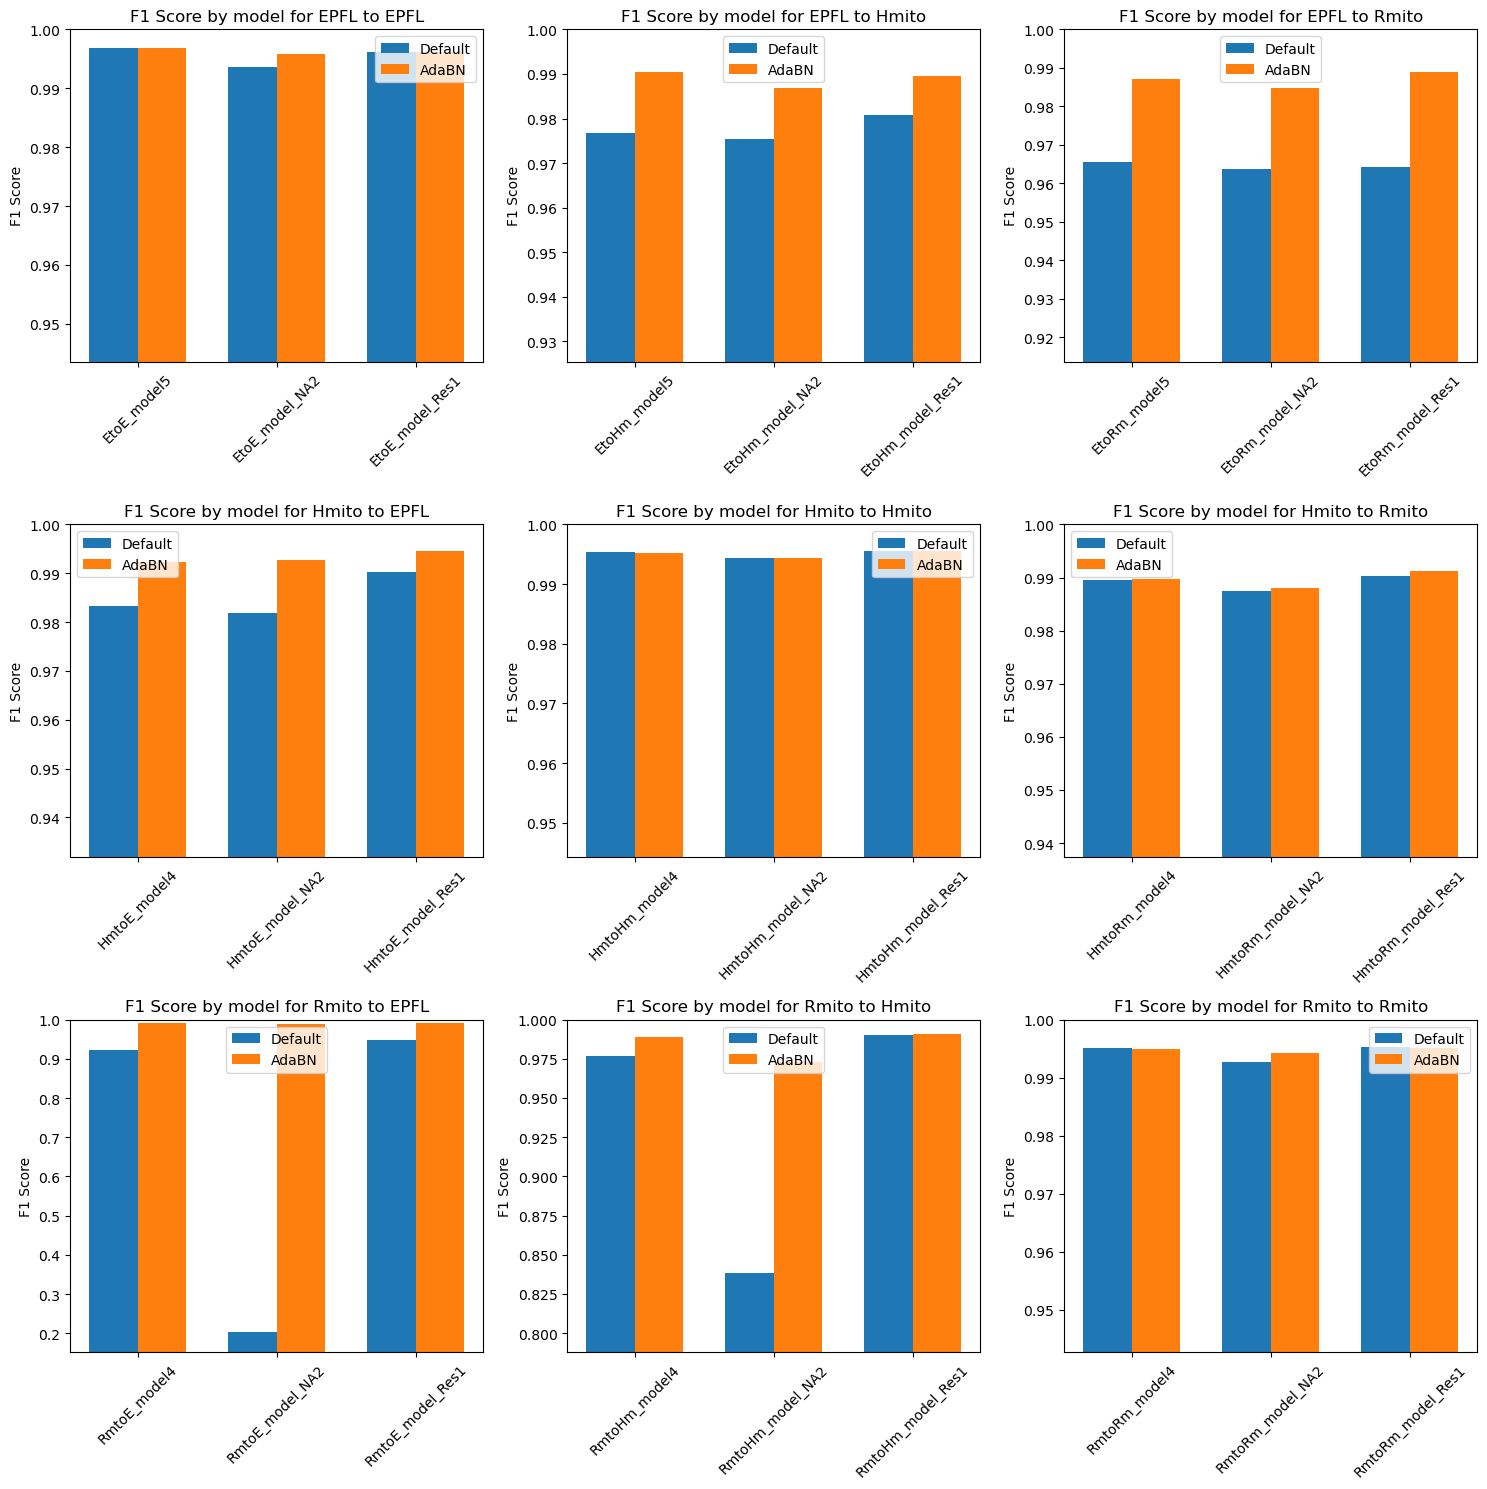

In [7]:
# plot all mito data

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

mito_data = ['EPFL', 'Hmito', 'Rmito']

for ax, (source, target) in zip(axes.flatten(), [(s, t) for s in mito_data for t in mito_data]):
    gap = f'{source}_to_{target}_gap'
    #print(f"Plotting {gap}... on axis {ax}")
    plot_bar_chart(gap, ax=ax)



plt.tight_layout()
plt.show()

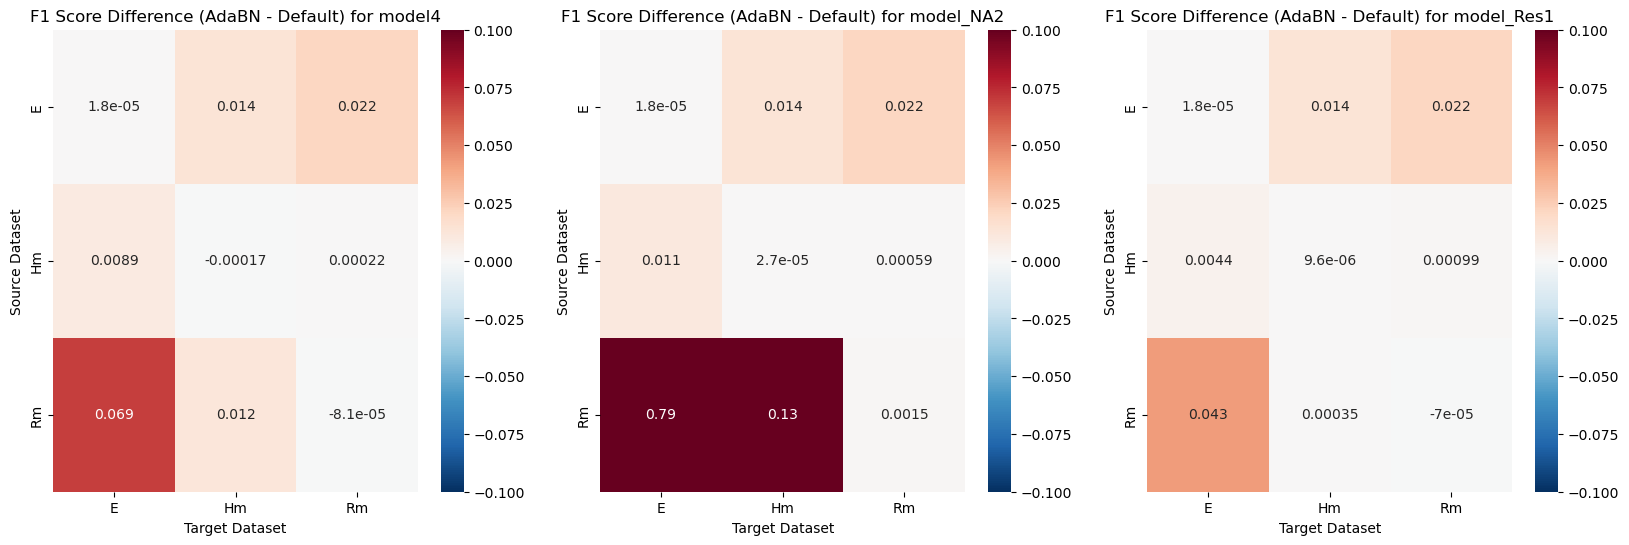

In [10]:
# heatmap for every model type

mito_data = ['E', 'Hm', 'Rm']
model_types = ['model4', 'model_NA2', 'model_Res1']

# make subplot for each model type
fig, axes = plt.subplots(1, len(model_types), figsize=(20, 6))

for model_type in model_types:
    heatmap_data = np.zeros((len(mito_data), len(mito_data)))

    for i, source in enumerate(mito_data):
        for j, target in enumerate(mito_data):
            source_name = source_model_mapping[source]
            target_name = source_model_mapping[target]
            gap = f'{source_name}_to_{target_name}_gap'
            
            gap_model = f'{source}to{target}_{model_type}'
            default_model = f'{source}_{model_type}'

            if source == 'E':
                gap_model = f'{source}to{target}_model5'
                default_model = f'{source}_model5'     

            #print(f"Calculating F1 difference for {gap_model} and {default_model}...")

            gap_f1_median = get_summary_metric(target_name, gap_model, "F1_eval", "adabn")[2][0]
            default_f1_median = get_summary_metric(target_name, default_model, "F1_eval", "default_training")[2][0]

            heatmap_data[i, j] = gap_f1_median - default_f1_median



    sns.heatmap(heatmap_data, xticklabels=mito_data, yticklabels=mito_data, annot=True, cmap='RdBu_r', center=0, vmin=-0.1, vmax=0.1, ax=axes[model_types.index(model_type)])
    axes[model_types.index(model_type)].set_title(f'F1 Score Difference (AdaBN - Default) for {model_type}')
    axes[model_types.index(model_type)].set_xlabel('Target Dataset')
    axes[model_types.index(model_type)].set_ylabel('Source Dataset')
    #plt.figure(figsize=(8, 6)) --- IGNORE ---
    #sns.heatmap(heatmap_data, xticklabels=mito_data, yticklabels=mito_data, annot=True, cmap='RdBu_r', center=0, vmin=-0.1, vmax=0.1) --- IGNORE ---
    #plt.title(f'F1 Score Difference (AdaBN - Default) for {model_type}') --- IGNORE ---
    #plt.xlabel('Target Dataset') --- IGNORE ---




## Nuclei evaluation

<Figure size 1500x1000 with 0 Axes>

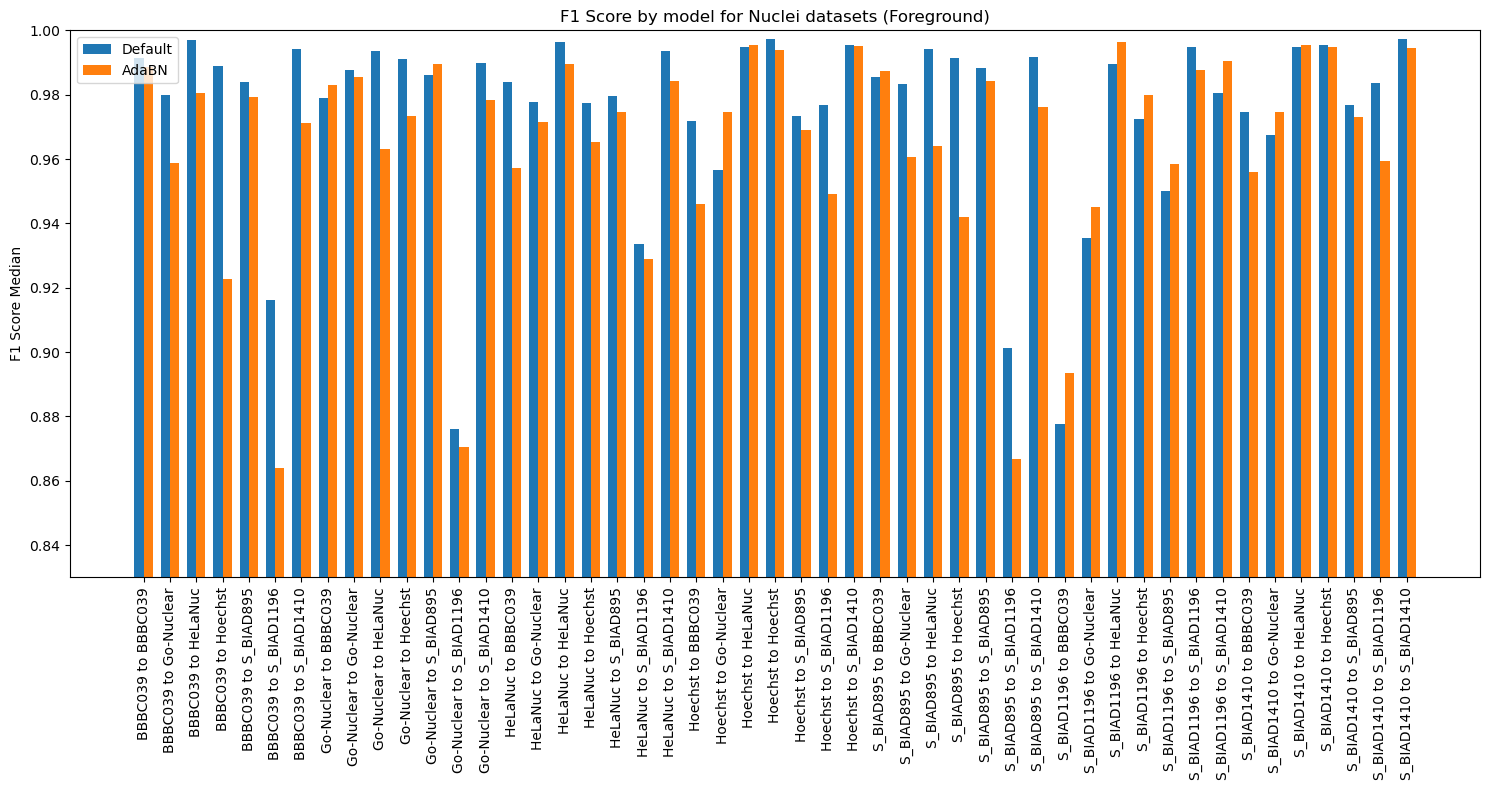

In [ ]:
# Plotting all nuclei data in one bar chart figure

fig = plt.figure(figsize=(15, 10))
nuclei_data = ['BBBC039', 'Go-Nuclear', 'HeLaNuc', 'Hoechst', 'S_BIAD895', 'S_BIAD1196', 'S_BIAD1410']

F1_default_means_fg = []
F1_ada_means_fg = []   

F1_default_means_bg = []
F1_ada_means_bg = []

for source in nuclei_data:
        for target in nuclei_data:
            gap = f'{source}_to_{target}_gap'
            gap_models = gap_models_nuc[gap]
            model_name = gap_models[0]
            #print(f"Getting {gap} model called {gap_models[0]}...")
    
            model_identifier = model_name.split("_")[0]
            #print(f"Initial model identifier: {model_identifier}")
            if "to" in model_identifier:
                model_identifier = model_identifier.split("to")[0]
            
            #print(f"Model identifier: {model_identifier}")
    
            F1_ada, F1_ada_mean, F1_ada_median = get_summary_metric(target, model_name, "F1_eval", "adabn")
            F1_default, F1_default_mean, F1_default_median = get_summary_metric(target, models_nuc[source], "F1_eval", "default_training")
            F1_default_means_fg.append(F1_default_median[0])
            F1_ada_means_fg.append(F1_ada_median[0])


plt.figure(figsize=(15, 8))

x = np.arange(len(F1_default_means_fg))
width = 0.35
plt.bar(x - width/2, F1_default_means_fg, width, label='Default')
plt.bar(x + width/2, F1_ada_means_fg, width, label='AdaBN')
plt.ylim(0.85, 1)  # Set y-axis limits to [0, 1]
plt.ylabel('F1 Score Median')
plt.title('F1 Score by model for Nuclei datasets (Foreground)')
plt.xticks(x, [f'{s} to {t}' for s in nuclei_data for t in nuclei_data], rotation=90)
plt.legend()
plt.tight_layout()
plt.show()
            

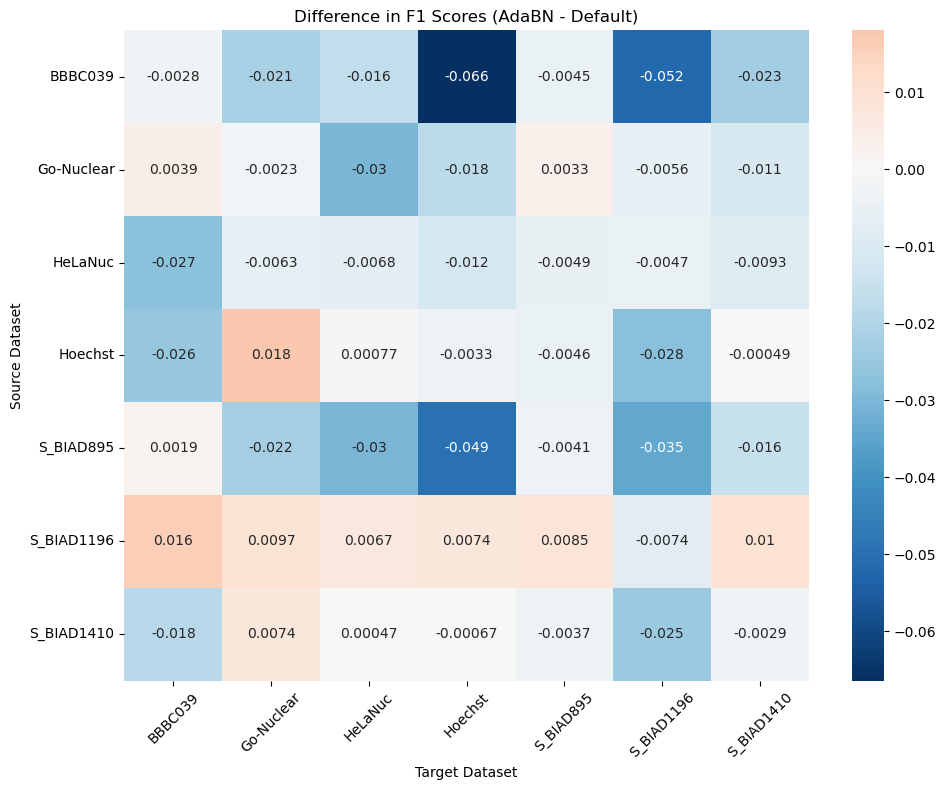

In [43]:
# plotting a heatmap of the F1 scores for all nuclei datasets 

nuclei_data = ['BBBC039', 'Go-Nuclear', 'HeLaNuc', 'Hoechst', 'S_BIAD895', 'S_BIAD1196', 'S_BIAD1410']

fg_medians_ada = np.zeros((len(nuclei_data), len(nuclei_data)))
fg_medians_default = np.zeros((len(nuclei_data), len(nuclei_data)))

for source in nuclei_data:
     for target in nuclei_data:
        gap = f'{source}_to_{target}_gap'
        gap_models = gap_models_nuc[gap]
        model_name = gap_models[0]
        #print(f"Getting {gap} model called {gap_models[0]}...")

        model_identifier = model_name.split("_")[0]
        #print(f"Initial model identifier: {model_identifier}")
        if "to" in model_identifier:
            model_identifier = model_identifier.split("to")[0]
        
        #print(f"Model identifier: {model_identifier}")

        F1_ada, F1_ada_mean, F1_ada_median = get_summary_metric(target, model_name, "F1_eval", "adabn")
        F1_default, F1_default_mean, F1_default_median = get_summary_metric(target, models_nuc[source], "F1_eval", "default_training")
        source_idx = nuclei_data.index(source)
        target_idx = nuclei_data.index(target)
        fg_medians_ada[source_idx, target_idx] = F1_ada_median[0]
        fg_medians_default[source_idx, target_idx] = F1_default_median[0]


difference_matrix = fg_medians_ada - fg_medians_default

import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(difference_matrix, xticklabels=nuclei_data, yticklabels=nuclei_data, annot=True, cmap="RdBu_r", center=0)
plt.title('Difference in F1 Scores (AdaBN - Default)')
plt.xlabel('Target Dataset')
plt.ylabel('Source Dataset')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



### Foreground ratio test

In [9]:
# plot foreground test
target = 'Go-Nuclear'
model_gap = '1196toGN_model3'
model_name = models_nuc["S_BIAD1196"]

F1_ada, F1_ada_mean, F1_ada_median = get_summary_metric(target, model_gap, "F1_eval", "adabn")
F1_default, F1_default_mean, F1_default_median = get_summary_metric(target, model_name, "F1_eval", "default_training")
F1_fg_01, F1_fg_01_mean, F1_fg_01_median = get_summary_metric(target, model_gap, "F1_eval", "adabn_fg_01")

print(F1_ada_median[0], F1_fg_01_median[0], F1_default_median[0])

0.9450979 0.9450979 0.9353881


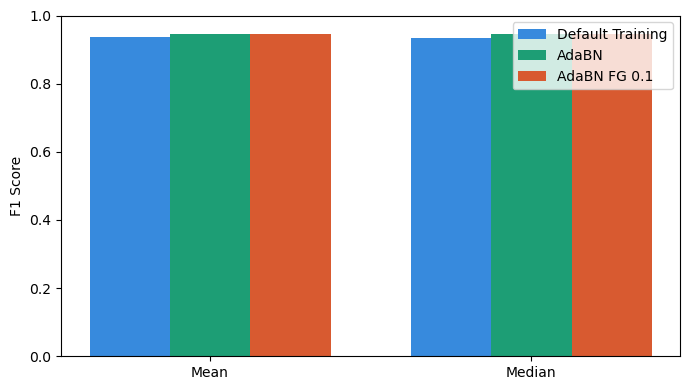

[np.float32(0.93545884), np.float32(0.9353881)] [np.float32(0.9443547), np.float32(0.9450979)] [np.float32(0.94435036), np.float32(0.9450979)]


In [16]:

labels = ['Mean', 'Median']
default = [F1_default_mean[0],       F1_default_median[0]]
adabn   = [F1_ada_mean[0],           F1_ada_median[0]]
fg_01   = [F1_fg_01_mean[0],         F1_fg_01_median[0]]

x = np.arange(len(labels))
w = 0.25

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - w, default, w, label='Default Training', color='#378ADD')
ax.bar(x,     adabn,   w, label='AdaBN',            color='#1D9E75')
ax.bar(x + w, fg_01,   w, label='AdaBN FG 0.1',     color='#D85A30')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

print(default, adabn, fg_01)

### Percentage Tests

In [ ]:
# plot 50 pct, 100 pct, default on HmtoE_model4

F1_50pct, F1_50pct_mean, F1_50pct_median = get_summary_metric("EPFL", "HmtoE_model4", "F1_eval", "adabn_pct50")
F1_100pct, F1_100pct_mean, F1_100pct_median = get_summary_metric("EPFL", "HmtoE_model4", "F1_eval", "adabn")
F1_default, F1_default_mean, F1_default_median = get_summary_metric("EPFL", "Hm_model4", "F1_eval", "default_training")

print(F1_100pct_median[0], F1_50pct_median[0], F1_default_median[0])

0.99223655 0.99301994 0.98332584


In [16]:
approach_pct = ['adabn', 'adabn_pct25', 'adabn_pct50', 'adabn_pct75']

source = 'EPFL'
models_Hm = gap_models_mito['EPFL_to_Hmito_gap']
models_Rm = gap_models_mito['EPFL_to_Rmito_gap']

median_default_Rm = [get_summary_metric('Rmito', model, "F1_eval", "default_training")[2][0] for model in models_mito['EPFL']]
median_default_Hm =  [get_summary_metric('Hmito', model, "F1_eval", "default_training")[2][0] for model in models_mito['EPFL']]

median_adabn100_Rm = [get_summary_metric('Rmito', gap_model, "F1_eval", "adabn")[2][0] for gap_model in models_Rm]
median_adabn100_Hm = [get_summary_metric('Hmito', gap_model, "F1_eval", "adabn")[2][0] for gap_model in models_Hm]

median_adabn75_Rm = [get_summary_metric('Rmito', gap_model, "F1_eval", "adabn_pct75")[2][0] for gap_model in models_Rm]
median_adabn75_Hm = [get_summary_metric('Hmito', gap_model, "F1_eval", "adabn_pct75")[2][0] for gap_model in models_Hm]

median_adabn50_Rm = [get_summary_metric('Rmito', gap_model, "F1_eval", "adabn_pct50")[2][0] for gap_model in models_Rm]
median_adabn50_Hm = [get_summary_metric('Hmito', gap_model, "F1_eval", "adabn_pct50")[2][0] for gap_model in models_Hm]

median_adabn25_Rm = [get_summary_metric('Rmito', gap_model, "F1_eval", "adabn_pct25")[2][0] for gap_model in models_Rm]
median_adabn25_Hm = [get_summary_metric('Hmito', gap_model, "F1_eval", "adabn_pct25")[2][0] for gap_model in models_Hm]


print(median_default_Rm[0], median_adabn100_Rm[0], median_adabn75_Rm[0], median_adabn50_Rm[0], median_adabn25_Rm[0])
print(median_default_Hm[0], median_adabn100_Hm[0], median_adabn75_Hm[0], median_adabn50_Hm[0], median_adabn25_Hm[0])


0.9655795 0.98713124 0.98723954 0.9872353 0.98734015
0.97675693 0.99048793 0.99053144 0.9905296 0.9905168


In [9]:
ADABN_APPROACHES = ["adabn", "adabn_pct25", "adabn_pct50", "adabn_pct75"]
SOURCE = "EPFL"
METRIC = "F1_eval"

models_Hm = gap_models_mito["EPFL_to_Hmito_gap"]   # gap models → Rmito target
models_Rm = gap_models_mito["EPFL_to_Rmito_gap"]    # gap models → Hmito target

def collect_medians(target: str, models: list, approach: str) -> list:
    return [
        get_summary_metric(target, model, METRIC, approach)[2][0]
        for model in models
    ]

median_default_Rm = collect_medians("Rmito", models_mito[SOURCE], "default_training")
median_default_Hm = collect_medians("Hmito", models_mito[SOURCE], "default_training")

adabn_results = {
    approach: {
        "Rm": collect_medians("Rmito", models_Rm, approach),
        "Hm": collect_medians("Hmito", models_Hm, approach),
    }
    for approach in ADABN_APPROACHES
}

median_adabn100_Rm, median_adabn100_Hm = adabn_results["adabn"]["Rm"],        adabn_results["adabn"]["Hm"]
median_adabn75_Rm,  median_adabn75_Hm  = adabn_results["adabn_pct75"]["Rm"],  adabn_results["adabn_pct75"]["Hm"]
median_adabn50_Rm,  median_adabn50_Hm  = adabn_results["adabn_pct50"]["Rm"],  adabn_results["adabn_pct50"]["Hm"]
median_adabn25_Rm,  median_adabn25_Hm  = adabn_results["adabn_pct25"]["Rm"],  adabn_results["adabn_pct25"]["Hm"]

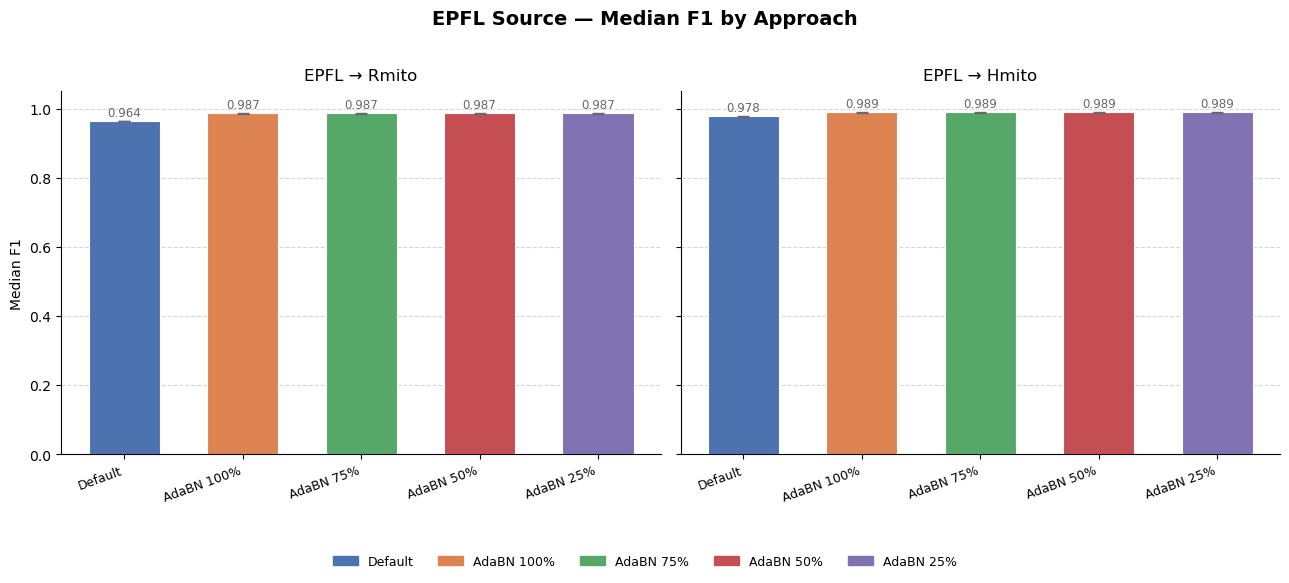

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Plot settings ─────────────────────────────────────────────────────────────
APPROACHES = {
    "Default":      {"Rm": median_default_Rm,    "Hm": median_default_Hm},
    "AdaBN 100%":   {"Rm": median_adabn100_Rm,   "Hm": median_adabn100_Hm},
    "AdaBN 75%":    {"Rm": median_adabn75_Rm,    "Hm": median_adabn75_Hm},
    "AdaBN 50%":    {"Rm": median_adabn50_Rm,    "Hm": median_adabn50_Hm},
    "AdaBN 25%":    {"Rm": median_adabn25_Rm,    "Hm": median_adabn25_Hm},
}

COLORS = {
    "Default":    "#4C72B0",
    "AdaBN 100%": "#DD8452",
    "AdaBN 75%":  "#55A868",
    "AdaBN 50%":  "#C44E52",
    "AdaBN 25%":  "#8172B3",
}

TARGETS = {
    "Rm": "EPFL → Rmito",
    "Hm": "EPFL → Hmito",
}

# ── Helper: aggregate scores per approach ────────────────────────────────────
def approach_stats(scores: list) -> tuple[float, float]:
    """Return (mean, std) across models."""
    arr = np.array(scores)
    return arr.mean(), arr.std()

# ── Build figure ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
fig.suptitle("EPFL Source — Median F1 by Approach", fontsize=14, fontweight="bold", y=1.02)

n_approaches = len(APPROACHES)
x = np.arange(n_approaches)
bar_width = 0.6

for ax, (target_key, target_label) in zip(axes, TARGETS.items()):
    labels, means, stds = [], [], []

    for approach_label, data in APPROACHES.items():
        m, s = approach_stats(data[target_key])
        labels.append(approach_label)
        means.append(m)
        stds.append(s)

    bars = ax.bar(
        x, means,
        width=bar_width,
        color=[COLORS[lbl] for lbl in labels],
        yerr=stds,
        capsize=4,
        edgecolor="white",
        linewidth=0.8,
        error_kw=dict(elinewidth=1.2, ecolor="dimgray"),
    )

    # Value labels on top of each bar
    for bar, mean in zip(bars, means):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{mean:.3f}",
            ha="center", va="bottom",
            fontsize=8.5, color="dimgray",
        )

    ax.set_title(target_label, fontsize=12, pad=8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=9)
    ax.set_ylabel("Median F1" if ax == axes[0] else "")
    ax.set_ylim(0, 1.05)
    ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

# ── Shared legend ─────────────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(color=color, label=label)
    for label, color in COLORS.items()
]
fig.legend(
    handles=legend_patches,
    loc="lower center",
    ncol=n_approaches,
    bbox_to_anchor=(0.5, -0.12),
    frameon=False,
    fontsize=9,
)

plt.tight_layout()
#plt.savefig("epfl_f1_barplot.pdf", bbox_inches="tight")
plt.show()